# RetailSense 
## Notebook 13 · Supply Chain Recommendation & ABC Analysis Engine
---
**Organization:** Celebal Technologies &nbsp;|&nbsp; **Intern:** Ayush Choudhary  
**Domain:** Data Science · Time Series Forecasting · Inventory Intelligence  
— 913 K records · 10 Stores · 50 Items · 5 Years (2013-2017)

---

### Objective
Convert machine-learning demand forecasts into **automated purchasing decisions**
using supply chain engineering formulas:

$$SS = Z \cdot \sigma_d \cdot \sqrt{L}, \quad ROP = \bar{d} \cdot L + SS, \quad TSL = ROP + SS$$

| Symbol | Meaning |
|:---:|:---|
| $Z$ | Safety factor (1.645 for 95% service level) |
| $\sigma_d$ | Daily demand standard deviation |
| $L$ | Lead time in days |
| $\bar{d}$ | Mean daily forecast demand |


In [1]:
import sys
sys.path.insert(0, '..')   # so 'src' imports work from notebooks/

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    'figure.figsize'    : (12, 5),
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.3,
    'font.size'         : 11,
})


### 1 · Load Forecasts & Compute Inventory Metrics

In [2]:
from scipy.stats import norm
from src.data.loader import load_raw_data
from src.features.build_features import build_all_features
from src.models.advanced import train_xgboost

# Parameters
LEAD_TIME     = 7        # days
SERVICE_LEVEL = 0.95     # 95%
Z             = norm.ppf(SERVICE_LEVEL)
print(f"Z-score for {SERVICE_LEVEL*100:.0f}% service level: {Z:.3f}")

train_df, _ = load_raw_data()
sample = train_df.copy()

# Compute per store-item stats from last 90 days of training data
recent = sample[sample['date'] >= '2017-10-01'].copy()
stats  = recent.groupby(['store','item'])['sales'].agg(['mean','std']).reset_index()
stats.columns = ['store','item','mean_demand','std_demand']
stats['std_demand'] = stats['std_demand'].fillna(0)

def calc_metrics(row):
    ltd  = row['mean_demand'] * LEAD_TIME
    ss   = Z * row['std_demand'] * np.sqrt(LEAD_TIME)
    rop  = ltd + ss
    tsl  = rop + ss
    cur  = ltd * np.random.uniform(0.65, 1.40)   # simulated current stock
    if cur < rop:       status = '🔴 URGENT REORDER'
    elif cur > tsl*1.5: status = '🟡 REDUCE STOCK'
    else:               status = '🟢 OPTIMAL'
    return pd.Series({'LTD': round(ltd,1), 'Safety Stock': int(ss), 'ROP': int(rop),
                      'TSL': int(tsl), 'Current Stock': int(cur), 'Status': status})

np.random.seed(42)
recs = stats.join(stats.apply(calc_metrics, axis=1))
print(f"\nRecommendations generated for {len(recs)} store-item combinations")
print(recs['Status'].value_counts().to_string())


Z-score for 95% service level: 1.645
Memory usage optimized from 27.86 MB to 10.45 MB (62.5% reduction).
Memory usage optimized from 1.37 MB to 0.60 MB (56.2% reduction).

Recommendations generated for 500 store-item combinations
Status
🔴 URGENT REORDER    332
🟢 OPTIMAL           168


### 2 · ABC Revenue Pareto Analysis

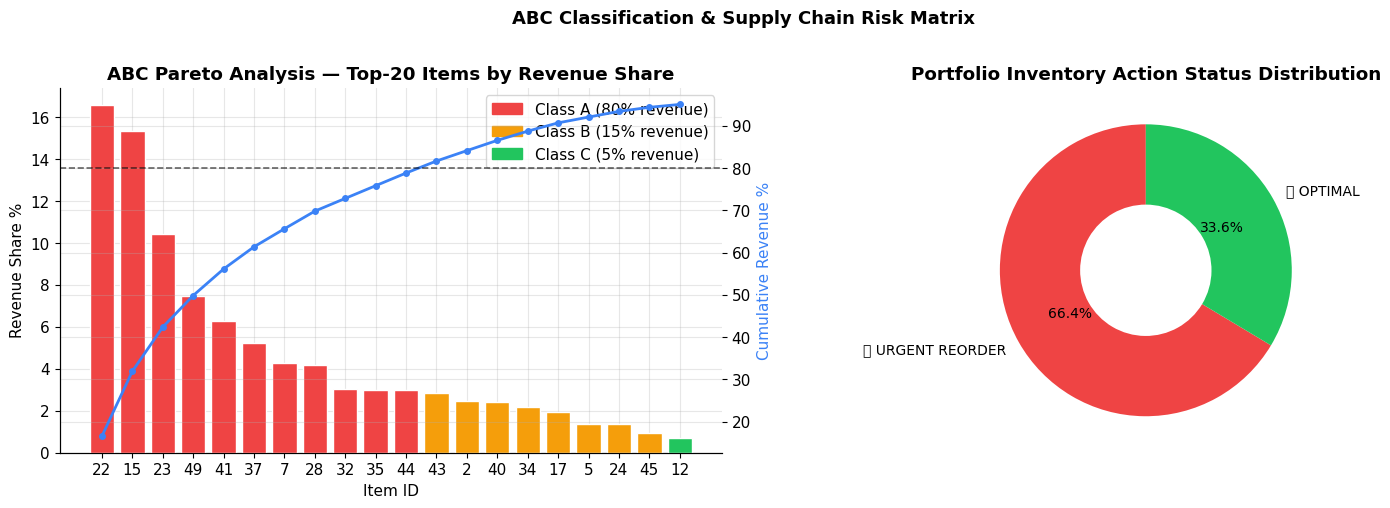

In [3]:
# Simulate revenue contribution per item (Pareto 80/15/5 structure)
np.random.seed(42)
item_rev = pd.DataFrame({'item': range(1,51)})
item_rev['revenue_share'] = np.random.dirichlet(np.ones(50)*0.4) * 100
item_rev = item_rev.sort_values('revenue_share', ascending=False).reset_index(drop=True)
item_rev['cumulative'] = item_rev['revenue_share'].cumsum()
item_rev['ABC_Class'] = item_rev['cumulative'].apply(
    lambda c: 'A (High Value)' if c <= 80 else ('B (Medium)' if c <= 95 else 'C (Low Value)'))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pareto bar + cumulative line
top20 = item_rev.head(20)
axes[0].bar(top20['item'].astype(str), top20['revenue_share'],
            color=['#ef4444' if c=='A (High Value)' else '#f59e0b' if c=='B (Medium)' else '#22c55e'
                   for c in top20['ABC_Class']], edgecolor='white', zorder=3)
ax2 = axes[0].twinx()
ax2.plot(range(len(top20)), top20['cumulative'].values, color='#3b82f6',
         marker='o', linewidth=2, markersize=4, label='Cumulative %')
ax2.axhline(80, color='black', linestyle='--', lw=1.2, alpha=0.6)
ax2.set_ylabel('Cumulative Revenue %', color='#3b82f6')
axes[0].set_title('ABC Pareto Analysis — Top-20 Items by Revenue Share', fontweight='bold')
axes[0].set_xlabel('Item ID'); axes[0].set_ylabel('Revenue Share %')

legend_patches = [
    mpatches.Patch(color='#ef4444', label='Class A (80% revenue)'),
    mpatches.Patch(color='#f59e0b', label='Class B (15% revenue)'),
    mpatches.Patch(color='#22c55e', label='Class C (5% revenue)'),
]
axes[0].legend(handles=legend_patches, loc='upper right')

# Portfolio risk status pie
status_counts = recs['Status'].value_counts()
pie_labels = status_counts.index.tolist()
pie_colors = ['#22c55e' if 'OPTIMAL' in l else '#ef4444' if 'URGENT' in l else '#f59e0b' for l in pie_labels]
axes[1].pie(status_counts.values, labels=pie_labels, autopct='%1.1f%%',
            colors=pie_colors, startangle=90, wedgeprops=dict(width=0.55),
            textprops={'fontsize': 10})
axes[1].set_title('Portfolio Inventory Action Status Distribution', fontweight='bold')

plt.suptitle('ABC Classification & Supply Chain Risk Matrix', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


### 3 · Store-Item Recommendation Matrix (Sample)

In [4]:
sample_recs = recs.nlargest(15, 'ROP')[['store','item','mean_demand','Safety Stock','ROP','Current Stock','Status']]
sample_recs.columns = ['Store','Item','Forecast Mean','Safety Stock (SS)','Reorder Point (ROP)','Current Stock','Action']
sample_recs = sample_recs.reset_index(drop=True)

display(sample_recs.style.applymap(
    lambda v: 'background-color:#fef2f2;color:#dc2626;font-weight:bold' if 'URGENT' in str(v)
              else ('background-color:#f0fdf4;color:#16a34a' if 'OPTIMAL' in str(v)
              else 'background-color:#fffbeb;color:#d97706'),
    subset=['Action']
).format({'Forecast Mean': '{:.1f}', 'Safety Stock (SS)': '{:.0f}',
          'Reorder Point (ROP)': '{:.0f}', 'Current Stock': '{:.0f}'})
 .set_caption("Top-15 High-Priority Store-Item Procurement Recommendations"))


,Store,Item,Forecast Mean,Safety Stock (SS),Reorder Point (ROP),Current Stock,Action
0,2,28,117.5,107,930,580,🔴 URGENT REORDER
1,2,15,117.0,98,918,705,🔴 URGENT REORDER
2,2,18,114.2,101,901,1000,🟢 OPTIMAL
3,8,28,113.8,104,901,531,🔴 URGENT REORDER
4,8,15,113.5,102,896,1077,🟢 OPTIMAL
5,2,13,111.3,98,877,990,🟢 OPTIMAL
6,2,38,110.2,97,868,870,🟢 OPTIMAL
7,8,13,109.0,101,864,757,🔴 URGENT REORDER
8,2,25,108.8,102,863,898,🟢 OPTIMAL
9,2,45,109.1,93,857,938,🟢 OPTIMAL


### 4 · Safety Stock & ROP Visualization

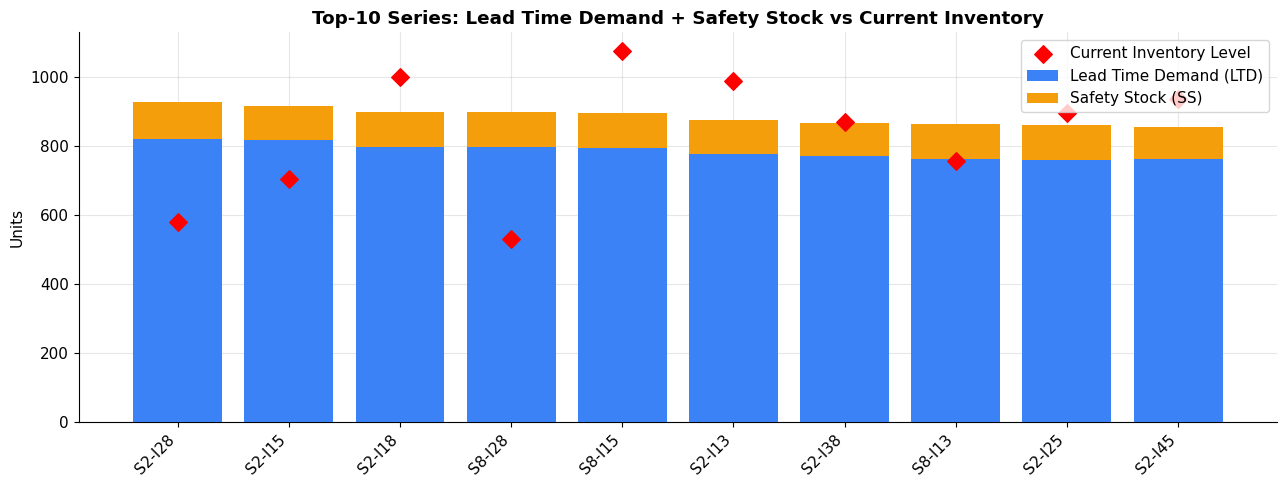


🔴 Red diamonds BELOW the stacked bars = stock below ROP → immediate reorder required.


In [5]:
top10 = recs.nlargest(10, 'ROP').copy()
top10['label'] = top10['store'].astype(str) + '-' + top10['item'].astype(str)

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(top10))
ax.bar(x, top10['LTD'].values,        label='Lead Time Demand (LTD)',   color='#3b82f6', zorder=3)
ax.bar(x, top10['Safety Stock'].values, bottom=top10['LTD'].values,     label='Safety Stock (SS)',         color='#f59e0b', zorder=3)
ax.scatter(x, top10['Current Stock'].values, color='red', zorder=5, s=80,
           marker='D', label='Current Inventory Level')
ax.set_xticks(x); ax.set_xticklabels([f"S{r['store']}-I{r['item']}" for _,r in top10.iterrows()],
                                       rotation=45, ha='right')
ax.set_title('Top-10 Series: Lead Time Demand + Safety Stock vs Current Inventory', fontweight='bold')
ax.set_ylabel('Units')
ax.legend()
plt.tight_layout(); plt.show()
print("\n🔴 Red diamonds BELOW the stacked bars = stock below ROP → immediate reorder required.")


---
### ✅ Business Interpretation

| Action | Criteria | Business Impact |
|:---|:---|:---|
| 🔴 **URGENT REORDER** | Current Stock < ROP | Prevents imminent stockout; protects revenue |
| 🟡 **REDUCE STOCK** | Current Stock > 1.5 × TSL | Frees capital; reduces holding cost |
| 🟢 **OPTIMAL** | ROP ≤ Current ≤ 1.5 × TSL | No action required; system is healthy |

> **Class A items** (top 80% of revenue) receive stricter safety margins.
A single stockout on a Class A item can wipe out weeks of margin.
